In [16]:
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [17]:
import os
DATA = "/Users/wusiyi/Documents/CASA/dis/DATA/"
print(os.listdir(DATA))

['westminster_fhrs_raw.csv', 'Loading-bays-consolidation.pdf', '.DS_Store', 'dft-road-casualty-statistics-vehicle-last-5-years.csv', 'soho_food_pois.csv', 'cycle-parking-map-info', 'soho_loading_bays.csv', 'files', 'cycle_parking.json', 'raw', 'dft-road-casualty-statistics-collision-last-5-years.csv']


In [18]:
import pandas as pd

acc = pd.read_csv(DATA + "dft-road-casualty-statistics-collision-last-5-years.csv", low_memory=False)
print(acc.shape)
print(acc.columns.tolist())

(503475, 44)
['collision_index', 'collision_year', 'collision_ref_no', 'location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude', 'police_force', 'collision_severity', 'number_of_vehicles', 'number_of_casualties', 'date', 'day_of_week', 'time', 'local_authority_district', 'local_authority_ons_district', 'local_authority_highway', 'local_authority_highway_current', 'first_road_class', 'first_road_number', 'road_type', 'speed_limit', 'junction_detail_historic', 'junction_detail', 'junction_control', 'second_road_class', 'second_road_number', 'pedestrian_crossing_human_control_historic', 'pedestrian_crossing_physical_facilities_historic', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards_historic', 'carriageway_hazards', 'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident', 'trunk_road_flag', 'lsoa_of_accident_location', 'enhanced_severity_collision', 'collision_in

In [19]:
import pandas as pd
import numpy as np

DATA = "/Users/wusiyi/Documents/CASA/dis/DATA/"

acc = pd.read_csv(DATA + "dft-road-casualty-statistics-collision-last-5-years.csv", low_memory=False)

# 时间字段
acc["hour"] = pd.to_datetime(acc["time"], format="%H:%M", errors="coerce").dt.hour
acc["date_dt"] = pd.to_datetime(acc["date"], format="%d/%m/%Y", errors="coerce")

# STATS19的day_of_week编码: 1=Sunday, 2=Monday ... 7=Saturday
dow_map = {1:"Sun", 2:"Mon", 3:"Tue", 4:"Wed", 5:"Thu", 6:"Fri", 7:"Sat"}
acc["dow"] = acc["day_of_week"].map(dow_map)

# Westminster全区(用ONS district名筛，先确认名称写法)
print(acc["local_authority_district"].dtype)
print(acc[acc["longitude"].between(-0.16,-0.11) & acc["latitude"].between(51.50,51.53)]["local_authority_district"].value_counts().head())

int64
local_authority_district
-1    3235
 1     415
 2     157
 9      19
 3      11
Name: count, dtype: int64


In [20]:
# Soho bbox —— 用你路网的实际值替换
minx, miny, maxx, maxy = -0.1420, 51.5090, -0.1290, 51.5190   # 示例值，请替换

# Westminster大致范围(备用，样本量不够时用)
wm = acc[acc["longitude"].between(-0.20, -0.11) & acc["latitude"].between(51.48, 51.54)]
soho = acc[acc["longitude"].between(minx, maxx) & acc["latitude"].between(miny, maxy)]

print("Westminster范围事故数:", len(wm))
print("Soho范围事故数:", len(soho))

# 筛两轮车：需要vehicle表
veh = pd.read_csv(DATA + "dft-road-casualty-statistics-vehicle-last-5-years.csv", low_memory=False)
print(veh.columns.tolist())
print(veh["vehicle_type"].value_counts().head(20))

Westminster范围事故数: 10571
Soho范围事故数: 594
['collision_index', 'collision_year', 'collision_ref_no', 'vehicle_reference', 'vehicle_type', 'towing_and_articulation', 'vehicle_manoeuvre_historic', 'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to', 'vehicle_location_restricted_lane_historic', 'vehicle_location_restricted_lane', 'junction_location', 'skidding_and_overturning', 'hit_object_in_carriageway', 'vehicle_leaving_carriageway', 'hit_object_off_carriageway', 'first_point_of_impact', 'vehicle_left_hand_drive', 'journey_purpose_of_driver_historic', 'journey_purpose_of_driver', 'sex_of_driver', 'age_of_driver', 'age_band_of_driver', 'engine_capacity_cc', 'propulsion_code', 'age_of_vehicle', 'generic_make_model', 'driver_imd_decile', 'lsoa_of_driver', 'escooter_flag', 'driver_distance_banding']
vehicle_type
 9     628614
 1      81231
 19     58092
 3      44442
 5      21819
 8      14360
 11     14290
 21     13115
 4       9489
-1       6545
 2       5323
 90      504

In [21]:
two_wheeler_codes = [1, 2, 3, 4, 5, 23, 97, 106]
tw_ids = veh[veh["vehicle_type"].isin(two_wheeler_codes)]["collision_index"].unique()

soho_tw = soho[soho["collision_index"].isin(tw_ids)]
wm_tw = wm[wm["collision_index"].isin(tw_ids)]

print("Soho两轮车事故:", len(soho_tw))
print("Westminster两轮车事故:", len(wm_tw))

# 小时分布
print(soho_tw.groupby("hour").size())

Soho两轮车事故: 319
Westminster两轮车事故: 6880
hour
0     14
1      5
2      4
3      4
5      4
6      4
7      6
8      8
9      7
10    11
11    14
12    22
13    19
14    19
15    17
16    21
17    27
18    28
19    24
20    12
21    15
22    18
23    16
dtype: int64


dow
Mon    41
Tue    45
Wed    44
Thu    55
Fri    56
Sat    42
Sun    36
Name: count, dtype: int64


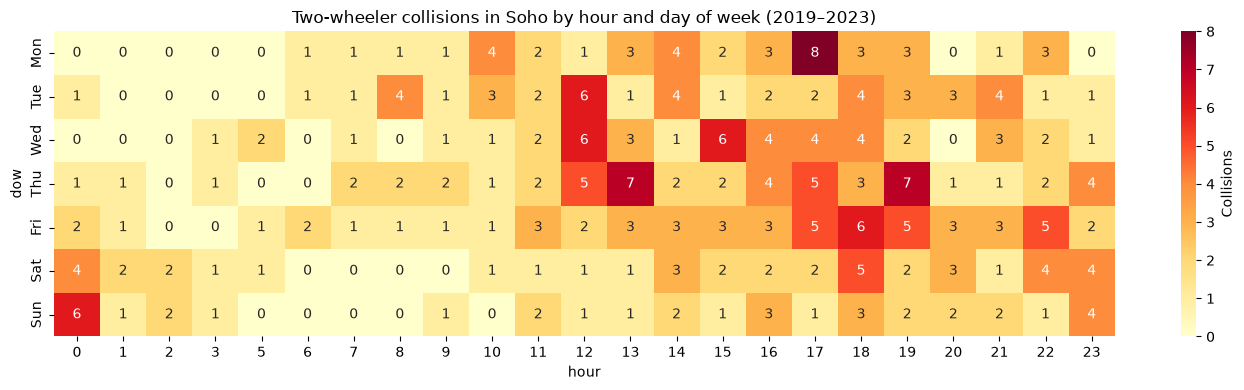

工作日小时分布:
hour
0      4
1      2
3      2
5      3
6      4
7      6
8      8
9      6
10    10
11    11
12    20
13    17
14    14
15    14
16    16
17    24
18    20
19    20
20     7
21    12
22    13
23     8
dtype: int64
escooter_flag
0    579
Name: count, dtype: int64


In [22]:
# 1. 周内分布 —— 回答周中vs周末
print(soho_tw["dow"].value_counts().reindex(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]))

# 2. weekday × hour 热力图（论文可直接用的图）
import matplotlib.pyplot as plt
import seaborn as sns

pivot = soho_tw.pivot_table(index="dow", columns="hour", aggfunc="size", fill_value=0)
pivot = pivot.reindex(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])

fig, ax = plt.subplots(figsize=(14,4))
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt="d", cbar_kws={"label":"Collisions"}, ax=ax)
ax.set_title("Two-wheeler collisions in Soho by hour and day of week (2019–2023)")
plt.tight_layout()
plt.savefig(DATA + "soho_tw_heatmap.png", dpi=200)
plt.show()

# 3. 只看工作日的小时分布（排除周末干扰）
weekday = soho_tw[soho_tw["dow"].isin(["Mon","Tue","Wed","Thu","Fri"])]
print("工作日小时分布:")
print(weekday.groupby("hour").size())

# 4. 看e-scooter和出行目的
print(veh[veh["collision_index"].isin(soho_tw["collision_index"])]["escooter_flag"].value_counts())

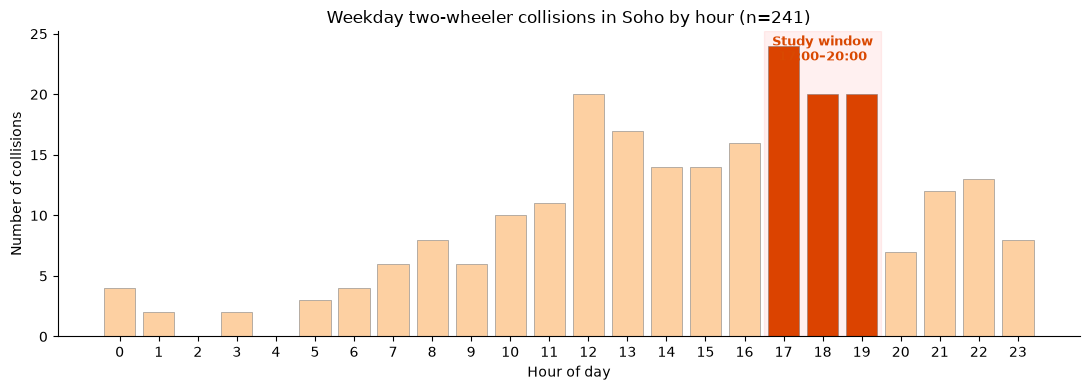

In [23]:
import matplotlib.pyplot as plt

counts = weekday.groupby("hour").size().reindex(range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#d94801" if h in [17,18,19] else "#fdd0a2" for h in range(24)]
ax.bar(range(24), counts.values, color=colors, edgecolor="grey", linewidth=0.4)

ax.axvspan(16.5, 19.5, color="red", alpha=0.06)
ax.text(18, counts.max()*0.95, "Study window\n17:00–20:00",
        ha="center", fontsize=9, color="#d94801", fontweight="bold")

ax.set_xticks(range(24))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of collisions")
ax.set_title("Weekday two-wheeler collisions in Soho by hour (n=241)")
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(DATA + "soho_weekday_hourly.png", dpi=200)
plt.show()

In [24]:
# ── 1. 月份分布：直接回答"选哪个季节" ──
weekday["month"] = weekday["date_dt"].dt.month
m = weekday.groupby("month").size().reindex(range(1,13), fill_value=0)
print("工作日全天 按月:\n", m)

# 只看目标时段17-19点的月份分布（更精准）
w1719 = weekday[weekday["hour"].isin([17,18,19])]
m2 = w1719.groupby("month").size().reindex(range(1,13), fill_value=0)
print("\n17-19点 按月:\n", m2)
print("17-19点总数:", len(w1719))

工作日全天 按月:
 month
1     14
2     13
3     20
4     14
5     25
6     14
7     26
8     19
9     34
10    26
11    20
12    16
dtype: int64

17-19点 按月:
 month
1      2
2      4
3     10
4      2
5      5
6      6
7      9
8      3
9      8
10     6
11     5
12     4
dtype: int64
17-19点总数: 64


In [25]:
# ── 2. 光照条件：17-19点在不同月份是白天还是黑夜 ──
# light_conditions: 1=Daylight, 4=Darkness lights lit, 5=Darkness lights unlit,
#                   6=Darkness no lighting, 7=Darkness lighting unknown
print(w1719["light_conditions"].value_counts())

# 交叉看：月份 × 光照
ct = pd.crosstab(w1719["month"], w1719["light_conditions"])
print("\n月份 × 光照:\n", ct)

light_conditions
1    38
4    24
7     1
5     1
Name: count, dtype: int64

月份 × 光照:
 light_conditions  1  4  5  7
month                       
1                 0  2  0  0
2                 0  4  0  0
3                 3  7  0  0
4                 2  0  0  0
5                 5  0  0  0
6                 6  0  0  0
7                 9  0  0  0
8                 3  0  0  0
9                 7  0  0  1
10                3  3  0  0
11                0  5  0  0
12                0  3  1  0


In [26]:
# ── 3. 天气：确认是否要排除雨天 ──
# weather_conditions: 1=Fine no wind, 2=Raining no wind, 3=Snowing,
#                     4=Fine+wind, 5=Raining+wind, 8=Other, 9=Unknown
print(w1719["weather_conditions"].value_counts())

weather_conditions
1    52
2     6
8     4
9     2
Name: count, dtype: int64


In [27]:
# ── 4. 年份趋势：确认疫情年份要不要排除 ──
print(weekday.groupby("collision_year").size())

collision_year
2020    39
2021    42
2022    60
2023    51
2024    49
dtype: int64


In [28]:
# 各区域两轮车事故密度对比
areas = {
    "Soho":        (-0.1420, 51.5090, -0.1290, 51.5190),
    "Mayfair":     (-0.1560, 51.5060, -0.1420, 51.5150),
    "Covent Gdn":  (-0.1290, 51.5090, -0.1180, 51.5170),
    "Fitzrovia":   (-0.1450, 51.5190, -0.1300, 51.5250),
}
for name, (x0,y0,x1,y1) in areas.items():
    sub = acc[acc.longitude.between(x0,x1) & acc.latitude.between(y0,y1)]
    sub_tw = sub[sub.collision_index.isin(tw_ids)]
    area_km2 = (x1-x0)*69*1.609*0.63 * (y1-y0)*69*1.609  # 粗略
    print(f"{name:12s} 两轮车事故 {len(sub_tw):4d}  密度 {len(sub_tw)/area_km2:.0f}/km²")

Soho         两轮车事故  319  密度 316/km²
Mayfair      两轮车事故  202  密度 206/km²
Covent Gdn   两轮车事故  191  密度 280/km²
Fitzrovia    两轮车事故  130  密度 186/km²


In [29]:
# 三个尺度并排看，直接验证Soho的时段是否特殊
for name, df in [("Soho", soho_tw), ("Westminster", wm_tw)]:
    wd = df[df["dow"].isin(["Mon","Tue","Wed","Thu","Fri"])]
    h = wd.groupby("hour").size().reindex(range(24), fill_value=0)
    print(f"\n{name} (n={len(wd)}):")
    print("  17-19点占比:", round(h[[17,18,19]].sum()/h.sum()*100, 1), "%")
    print("  峰值小时:", h.idxmax())
    print(h.values)


Soho (n=241):
  17-19点占比: 26.6 %
  峰值小时: 17
[ 4  2  0  2  0  3  4  6  8  6 10 11 20 17 14 14 16 24 20 20  7 12 13  8]

Westminster (n=5341):
  17-19点占比: 26.7 %
  峰值小时: 18
[ 60  25  19  19  10  43  95 279 364 248 236 233 293 308 273 318 380 496
 545 385 243 185 173 111]


In [30]:
# Soho + Covent Garden + Chinatown + Leicester Sq + Fitzrovia南部
# 这些区域功能同质（餐饮/夜间经济/窄街），合并后样本量上去了，机制还是一致的
west_end = acc[acc.longitude.between(-0.145, -0.118) & acc.latitude.between(51.508, 51.522)]
we_tw = west_end[west_end.collision_index.isin(tw_ids)]
we_wd = we_tw[we_tw.dow.isin(["Mon","Tue","Wed","Thu","Fri"])]
print("West End核心区工作日两轮车事故:", len(we_wd))
print(we_wd.groupby("hour").size().reindex(range(24), fill_value=0).values)

West End核心区工作日两轮车事故: 631
[ 9  2  5  3  3  3  9 21 26 33 25 38 43 42 33 34 35 63 58 48 28 23 29 18]


In [31]:
we_wd["month"] = we_wd["date_dt"].dt.month
we1719 = we_wd[we_wd["hour"].isin([17,18,19])]
print("17-19点样本:", len(we1719))
print("\n按月:\n", we1719.groupby("month").size().reindex(range(1,13), fill_value=0))
print("\n光照:\n", we1719["light_conditions"].value_counts())
print("\n月×光照:\n", pd.crosstab(we1719["month"], we1719["light_conditions"]))
print("\n按年:\n", we_wd.groupby("collision_year").size())

17-19点样本: 169

按月:
 month
1     10
2     12
3     25
4     10
5     10
6     16
7     15
8     16
9     19
10    13
11    15
12     8
dtype: int64

光照:
 light_conditions
1    92
4    72
7     3
5     2
Name: count, dtype: int64

月×光照:
 light_conditions   1   4  5  7
month                         
1                  0  10  0  0
2                  1  11  0  0
3                  8  16  0  1
4                  7   3  0  0
5                 10   0  0  0
6                 15   1  0  0
7                 14   0  1  0
8                 16   0  0  0
9                 14   4  0  1
10                 6   7  0  0
11                 1  13  0  1
12                 0   7  1  0

按年:
 collision_year
2020     89
2021    117
2022    151
2023    139
2024    135
dtype: int64


In [32]:
ct = pd.crosstab(we1719["month"], we1719["light_conditions"])
print(ct.to_string())

light_conditions   1   4  5  7
month                         
1                  0  10  0  0
2                  1  11  0  0
3                  8  16  0  1
4                  7   3  0  0
5                 10   0  0  0
6                 15   1  0  0
7                 14   0  1  0
8                 16   0  0  0
9                 14   4  0  1
10                 6   7  0  0
11                 1  13  0  1
12                 0   7  1  0
